In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
df=pd.read_csv("readmitted.csv")

In [33]:
df

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,12521,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,10155,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,12088,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,10792,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,10499,85,Male,23.2,249,136.4,0.84,126,102,0,0,1,0.54,Medium,9.1,1
2996,10747,70,Male,26.1,125,139.4,0.71,135,82,0,1,1,0.57,Medium,47.6,0
2997,11948,69,Male,30.0,362,134.2,1.95,148,61,0,0,1,0.99,Medium,31.7,1
2998,12148,90,Female,26.2,503,143.6,0.16,145,56,1,1,0,0.61,Low,39.0,1


In [34]:
df.head()

,patient_id,age,gender,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,income_level,distance_to_hospital_km,readmitted_30d
0,12911,76,Male,23.9,738,135.3,1.58,151,93,1,1,0,0.98,Medium,12.4,0
1,12521,77,Male,32.3,405,143.0,1.50,107,74,1,0,1,0.66,Medium,38.8,1
2,10155,42,Male,29.3,399,NaN,1.43,121,97,1,0,1,0.93,Low,43.5,1
3,12088,83,Female,29.1,524,135.1,0.91,114,66,0,1,1,0.54,Low,33.3,1
4,10792,48,Female,24.2,301,139.5,0.54,122,79,1,1,1,0.78,High,21.3,0


In [35]:
df.shape

(3000, 16)

In [36]:
numerical_cols=["age","bmi","bnp","creatinine","systolic_bp","heart_rate","adherence_score","distance_to_hospital_km"]

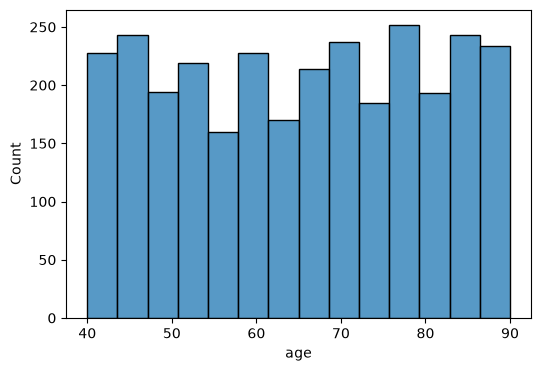

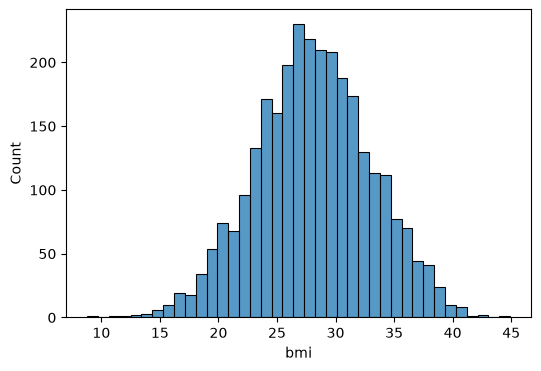

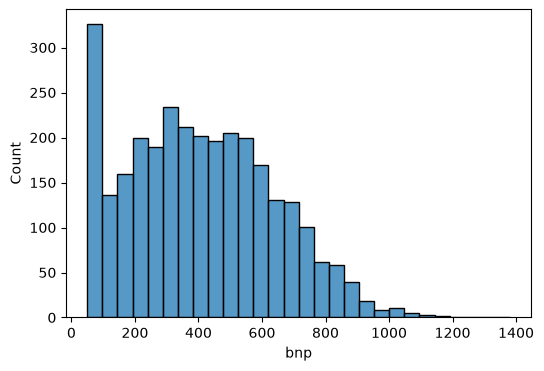

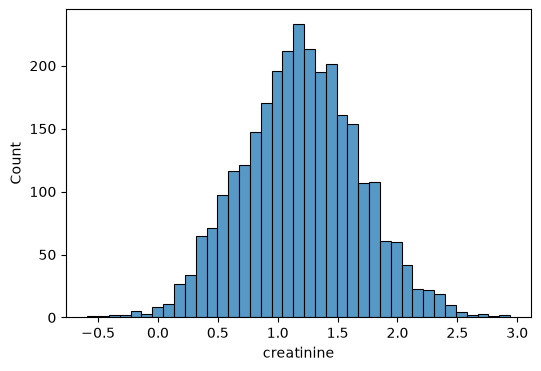

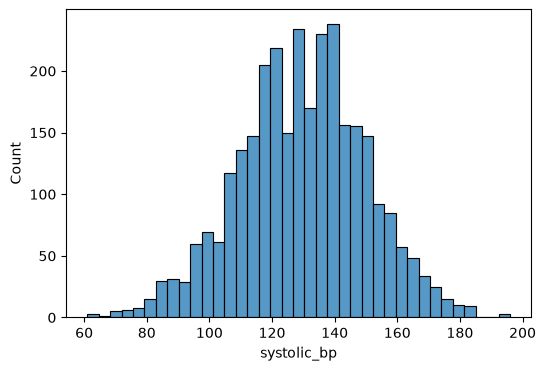

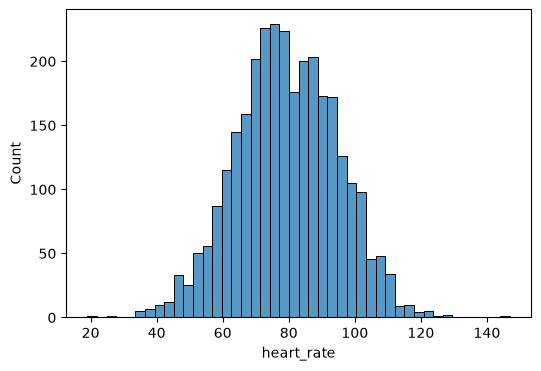

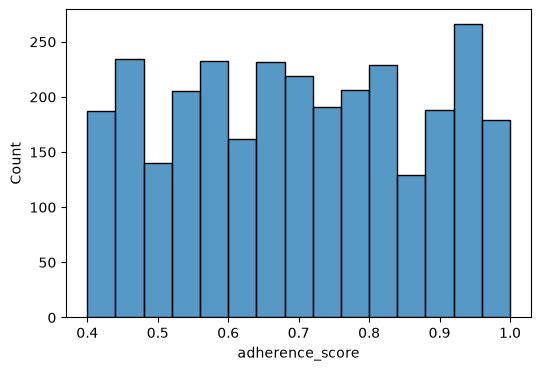

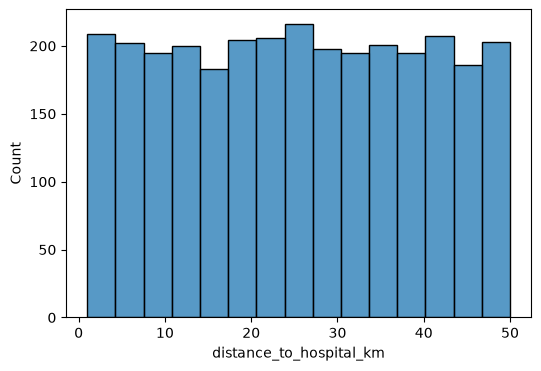

In [37]:
for t in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[t])

In [38]:
categorical_cols=["gender","ace_inhibitor",	"beta_blocker",	"diuretic","readmitted_30d","income_level"]

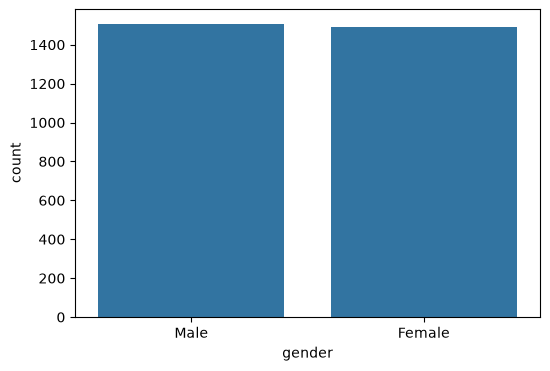

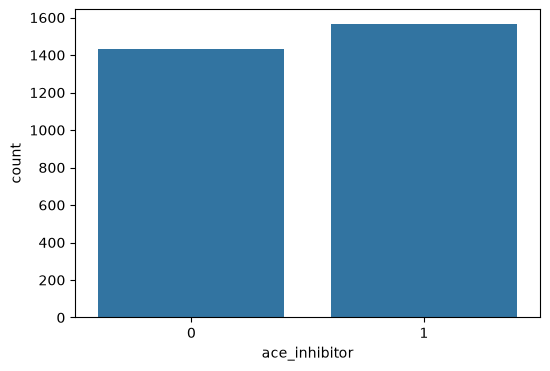

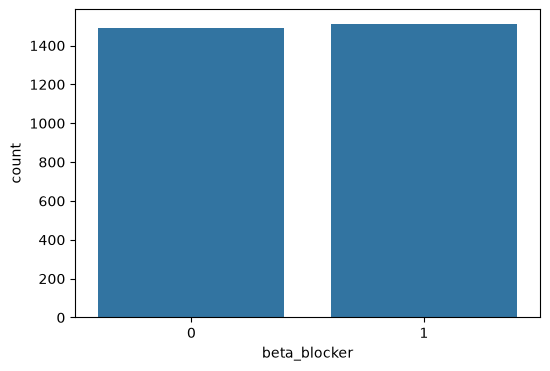

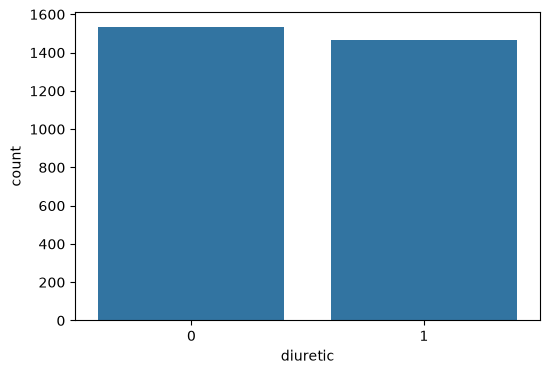

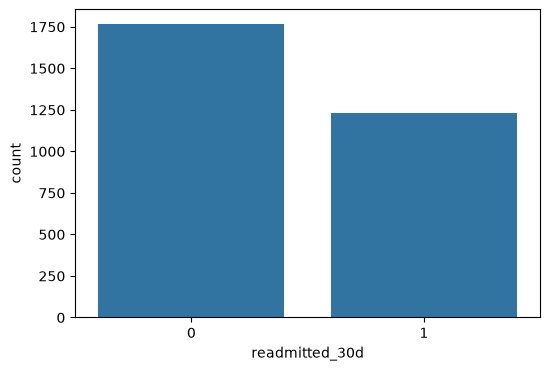

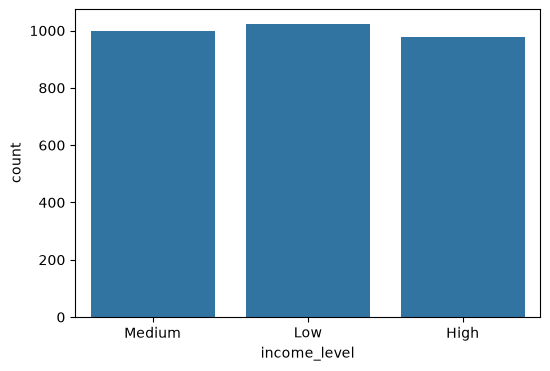

In [39]:
for p in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[p])

In [40]:
df.isnull().sum()

patient_id                  0
age                         0
gender                      0
bmi                        90
bnp                         0
sodium                     90
creatinine                 90
systolic_bp                 0
heart_rate                  0
ace_inhibitor               0
beta_blocker                0
diuretic                    0
adherence_score             0
income_level                0
distance_to_hospital_km     0
readmitted_30d              0
dtype: int64

In [41]:
df[["bmi","sodium","creatinine"]]=df[["bmi","sodium","creatinine"]].fillna(df[["bmi","sodium","creatinine"]].mean())

In [42]:
df.isnull().sum()

patient_id                 0
age                        0
gender                     0
bmi                        0
bnp                        0
sodium                     0
creatinine                 0
systolic_bp                0
heart_rate                 0
ace_inhibitor              0
beta_blocker               0
diuretic                   0
adherence_score            0
income_level               0
distance_to_hospital_km    0
readmitted_30d             0
dtype: int64

In [43]:
df=pd.get_dummies(df,columns=["gender","income_level"],drop_first=True,dtype=int)

In [44]:
df.head()

,patient_id,age,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,distance_to_hospital_km,readmitted_30d,gender_Male,income_level_Low,income_level_Medium
0,12911,76,23.9,738,135.30000,1.58,151,93,1,1,0,0.98,12.4,0,1,0,1
1,12521,77,32.3,405,143.00000,1.50,107,74,1,0,1,0.66,38.8,1,1,0,1
2,10155,42,29.3,399,138.08921,1.43,121,97,1,0,1,0.93,43.5,1,1,1,0
3,12088,83,29.1,524,135.10000,0.91,114,66,0,1,1,0.54,33.3,1,0,1,0
4,10792,48,24.2,301,139.50000,0.54,122,79,1,1,1,0.78,21.3,0,0,0,0


In [46]:
final_df =df [[
    "age",
    "bmi",
    "bnp",
    "sodium",
    "creatinine",
    "systolic_bp",
    "heart_rate",
    "ace_inhibitor",
    "beta_blocker",
    "diuretic",
    "adherence_score",
    "distance_to_hospital_km",
    "readmitted_30d",
    "gender_Male",
    "income_level_Low",
    "income_level_Medium"
]]
final_df.head()

,age,bmi,bnp,sodium,creatinine,systolic_bp,heart_rate,ace_inhibitor,beta_blocker,diuretic,adherence_score,distance_to_hospital_km,readmitted_30d,gender_Male,income_level_Low,income_level_Medium
0,76,23.9,738,135.30000,1.58,151,93,1,1,0,0.98,12.4,0,1,0,1
1,77,32.3,405,143.00000,1.50,107,74,1,0,1,0.66,38.8,1,1,0,1
2,42,29.3,399,138.08921,1.43,121,97,1,0,1,0.93,43.5,1,1,1,0
3,83,29.1,524,135.10000,0.91,114,66,0,1,1,0.54,33.3,1,0,1,0
4,48,24.2,301,139.50000,0.54,122,79,1,1,1,0.78,21.3,0,0,0,0


In [47]:
from sklearn.model_selection import train_test_split
X=final_df.drop("readmitted_30d",axis=1)
Y=final_df["readmitted_30d"]

In [48]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [53]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,Y_train)
y_pred=model.predict(X_test)

C:\Users\jai arora\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [55]:
y_prob = model.predict_proba(X_test)[:, 1]

In [57]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(Y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7083668543845535


In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(Y_test, y_pred)

print(cm)

[[299  75]
 [120 106]]


In [61]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.80      0.75       374
           1       0.59      0.47      0.52       226

    accuracy                           0.68       600
   macro avg       0.65      0.63      0.64       600
weighted avg       0.67      0.68      0.67       600



In [70]:
y_prob = model.predict_proba(X_test)[:, 1]

y_pred_30 = (y_prob >= 0.30).astype(int)

print(confusion_matrix(Y_test, y_pred_30))
print(classification_report(Y_test, y_pred_30))

[[115 259]
 [ 22 204]]
              precision    recall  f1-score   support

           0       0.84      0.31      0.45       374
           1       0.44      0.90      0.59       226

    accuracy                           0.53       600
   macro avg       0.64      0.61      0.52       600
weighted avg       0.69      0.53      0.50       600

